La idea del proceso de aprendizaje supervisado es el siguiente proceso:
1. Forward: Uitlizar datos de apredizaje y predecir un resultado.
2. Error: Calcular de alguna forma el error entre la predicción y el resultado real.
3. Backpropagation: El proceso de cambiar los parámetros en las neuronas con algún método que ayude a reducir el error.
4. Iterar los pasos anteriores.
5. Utilizar datos de validación para comprobar el aprendizaje y no la memorización u overfiting en el modelo.
![](Proceso_de_aprendizaje.png)

Un una red neuronal basada en un perceptron multicapas es una composición de neuronas con multiples capas (como una comosición de funciones lineales entre espacios de diferentes dimensiones)

![](Neural_network.png)

Para problemas de predicción de valores numéricos continuos lo usual es utilizar lo que se conoce como una red neuronal de regresion (RNN).

Analicemos un caso sencillo, una serie de datos numéricos, primero analizando el caso lineal para ver cómo funciona el algoritmo de aprendizaje.

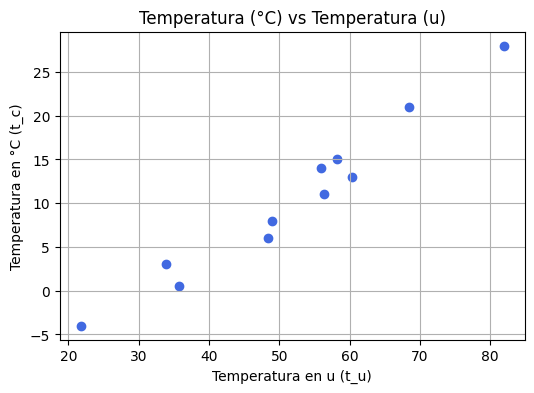

In [151]:
import torch
import matplotlib.pyplot as plt

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]      #Temperatura en grados C
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]  #En grados u

# Convertir a tensores
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

# Graficar
plt.figure(figsize=(6,4))
plt.scatter(t_u, t_c, color='royalblue', marker='o')  # puntos (x=t_u, y=t_c)
plt.title("Temperatura (°C) vs Temperatura (u)")
plt.xlabel("Temperatura en u (t_u)")
plt.ylabel("Temperatura en °C (t_c)")
plt.grid(True)
plt.show()

La imagen nos sirve para observar su comportammiento, en este caso se observa un comportamiento lineal. Se pueden calcular parámetros estadísticos para corroborar esto como la matriz de correlación, o el parámetro de Pearson.

In [14]:
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

# Coeficiente de correlación de Pearson con numpy
corr = np.corrcoef(t_c, t_u)    #solo llamamos la función
print(corr)

# Coeficiente de correlación de Pearson con scipy
r, p = pearsonr(t_c, t_u)
print(f"Coeficiente de Pearson: {r:.4f}")     #Coeficiente de correlación
print(f"Valor p: {p:.4e}")                    #Hipótesis

# Coeficiente de correlación de Pearson con pandas
df = pd.DataFrame({'t_c': t_c, 't_u': t_u})       #Se crea el data frame
print(df.corr())  # Matriz de correlación         #se llama la función

[[1.         0.98083936]
 [0.98083936 1.        ]]
Coeficiente de Pearson: 0.9808
Valor p: 1.0624e-07
          t_c       t_u
t_c  1.000000  0.980839
t_u  0.980839  1.000000


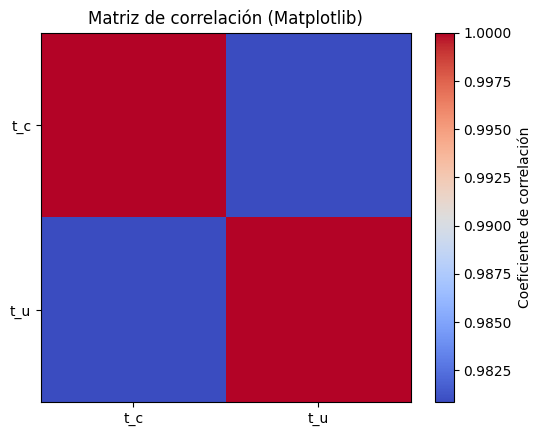

In [15]:
#Adicionalmente con matplotlib podemos crear un mapa de calor para observar esto
corr = df.corr()

plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Coeficiente de correlación')
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Matriz de correlación (Matplotlib)")
plt.show()

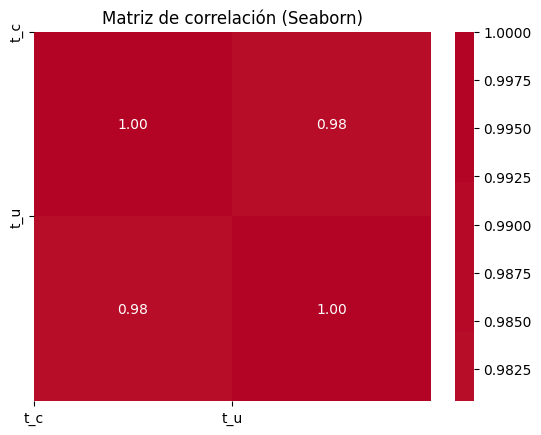

In [16]:
#Graficando con seaborn
import seaborn as sns

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Matriz de correlación (Seaborn)")
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

Lo anterior nos muestra una correlación casi lineal, entonces es válido proponer el modelo y = w*x + b

In [143]:
#Definimos el modelo
def model_T(t_u, w, b):
    return w * t_u + b

#Y para analizar su precision usamos el error cuadrático medio
def loss_fn(t_p, t_c):
    square_e = (t_p - t_c)**2
    return square_e.mean()

#Podemos proponer valores aleatorios para w,b, o prooponer unos, o zeros o ser creativos
w = torch.ones(())
b = torch.zeros(())

#Evaluamos el modelo
t_p = model_T(t_u, w, b)

t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [144]:
#Error usando error cuadrático promedio
loss = loss_fn(t_p,t_c)
loss

tensor(1763.8848)

Para este tipo de problemas lineales existen soluciones explícitas que resuelven el problema como el método de mínimos cuadrados de Legendre-Gauss. Para entender el método de aprendizaje sin embargo, vamos a buscar disminuir el error de manera iterativa lo que es más parecido al aprendizaje, se hará es usar el método de descenso de gradiente.

In [19]:
#Backpropagation usando descenso de gradiente
delta = 0.1      #Tamaño de paso para el cálculo numérico de las derivadas

#Derivada del error respecto a w
loss_rate_of_change_w = (loss_fn(model_T(t_u, w + delta, b), t_c) - loss_fn(model_T(t_u, w - delta, b), t_c)) / (2.0 * delta)

#Derivada del error respecto a b
loss_rate_of_change_b = (loss_fn(model_T(t_u, w, b + delta), t_c) - loss_fn(model_T(t_u, w, b - delta), t_c)) / (2.0 * delta)

#Actuallización de los valores
learning_rate = 1e-2       #Tamaño de paso para el aprendizaje
w = w - learning_rate * loss_rate_of_change_w
b = b - learning_rate * loss_rate_of_change_b

w,b

(tensor(-44.1730), tensor(-0.8260))

Para realizar todo este proceso de manera iterativa se debe calcular la derivada automáticamente

In [20]:
#Función derivada del error
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)
    return dsq_diffs

#Función derivada del modelo
def dmodel_dw(t_u, w, b):
    return t_u

def dmodel_db(t_u, w, b):
    return 1.0

def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

In [21]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params
        t_p = model_T(t_u, w, b)       #Forward pass
        loss = loss_fn(t_p, t_c)     #Error 
        grad = grad_fn(t_u, t_c, t_p, w, b)    #Backpropagation
        params = params - learning_rate * grad 
        print('Epoch %d, Loss %f' % (epoch, float(loss)))
        
    return params

In [22]:
training_loop(
n_epochs = 15,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0]),
t_u = t_u,
t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 5802484.500000
Epoch 3, Loss 19408029696.000000
Epoch 4, Loss 64915905708032.000000
Epoch 5, Loss 217130525461053440.000000
Epoch 6, Loss 726257583152928129024.000000
Epoch 7, Loss 2429183416467662896627712.000000
Epoch 8, Loss 8125122549611731432050262016.000000
Epoch 9, Loss 27176882120842590626938030653440.000000
Epoch 10, Loss 90901105189019073810297959556841472.000000
Epoch 11, Loss inf
Epoch 12, Loss inf
Epoch 13, Loss inf
Epoch 14, Loss inf
Epoch 15, Loss inf


tensor([-2.0798e+26, -3.6636e+24])

Aqui ocurre un sobre entrenamiento debido a que el tamaño de paso de aprendizaje es muy grande y causa esta divergencia

In [23]:
training_loop(
n_epochs = 20,
learning_rate = 1e-4,
params = torch.tensor([1.0, 0.0]),
t_u = t_u,
t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 323.090515
Epoch 3, Loss 78.929634
Epoch 4, Loss 37.552845
Epoch 5, Loss 30.540283
Epoch 6, Loss 29.351154
Epoch 7, Loss 29.148884
Epoch 8, Loss 29.113848
Epoch 9, Loss 29.107145
Epoch 10, Loss 29.105247
Epoch 11, Loss 29.104168
Epoch 12, Loss 29.103222
Epoch 13, Loss 29.102295
Epoch 14, Loss 29.101379
Epoch 15, Loss 29.100466
Epoch 16, Loss 29.099548
Epoch 17, Loss 29.098631
Epoch 18, Loss 29.097717
Epoch 19, Loss 29.096796
Epoch 20, Loss 29.095881


tensor([ 0.2323, -0.0196])

Ahora vemos que el modelo se estanca en un valro del error, la primera forma de atacar este problema será normalizar los datos de entrada

In [145]:
#Normalización con covarizanza y varianza 1
t_un = (t_u - t_u.mean())/t_u.std()
t_u, t_un

(tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
         48.4000, 60.4000, 68.4000]),
 tensor([-0.9565,  0.2436,  0.3802,  1.7883,  0.2673, -0.1723, -1.0635, -1.7823,
         -0.2020,  0.5109,  0.9862]))

In [25]:
#Entrenamiento con variables normalizadas
training_loop(
n_epochs = 320,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0]),
t_u = t_un,       #Cambio a las variables normalizadas
t_c = t_c)

Epoch 1, Loss 171.868347
Epoch 2, Loss 165.387650
Epoch 3, Loss 159.156021
Epoch 4, Loss 153.163925
Epoch 5, Loss 147.402084
Epoch 6, Loss 141.861664
Epoch 7, Loss 136.534119
Epoch 8, Loss 131.411301
Epoch 9, Loss 126.485237
Epoch 10, Loss 121.748444
Epoch 11, Loss 117.193611
Epoch 12, Loss 112.813728
Epoch 13, Loss 108.602043
Epoch 14, Loss 104.552116
Epoch 15, Loss 100.657707
Epoch 16, Loss 96.912842
Epoch 17, Loss 93.311745
Epoch 18, Loss 89.848923
Epoch 19, Loss 86.519020
Epoch 20, Loss 83.316940
Epoch 21, Loss 80.237762
Epoch 22, Loss 77.276787
Epoch 23, Loss 74.429413
Epoch 24, Loss 71.691315
Epoch 25, Loss 69.058289
Epoch 26, Loss 66.526276
Epoch 27, Loss 64.091408
Epoch 28, Loss 61.749950
Epoch 29, Loss 59.498318
Epoch 30, Loss 57.333035
Epoch 31, Loss 55.250809
Epoch 32, Loss 53.248425
Epoch 33, Loss 51.322838
Epoch 34, Loss 49.471081
Epoch 35, Loss 47.690319
Epoch 36, Loss 45.977833
Epoch 37, Loss 44.330997
Epoch 38, Loss 42.747280
Epoch 39, Loss 41.224274
Epoch 40, Loss 39.7

tensor([ 9.0123, 10.4837])

Vemos una gran mejora en el sentido de que el error ahora se estanca en valores más bajos

In [26]:
#Obtenemos los valores para los parámetros del entrenamiento
params = training_loop(
n_epochs = 320,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0]),
t_u = t_un,
t_c = t_c)

Epoch 1, Loss 171.868347
Epoch 2, Loss 165.387650
Epoch 3, Loss 159.156021
Epoch 4, Loss 153.163925
Epoch 5, Loss 147.402084
Epoch 6, Loss 141.861664
Epoch 7, Loss 136.534119
Epoch 8, Loss 131.411301
Epoch 9, Loss 126.485237
Epoch 10, Loss 121.748444
Epoch 11, Loss 117.193611
Epoch 12, Loss 112.813728
Epoch 13, Loss 108.602043
Epoch 14, Loss 104.552116
Epoch 15, Loss 100.657707
Epoch 16, Loss 96.912842
Epoch 17, Loss 93.311745
Epoch 18, Loss 89.848923
Epoch 19, Loss 86.519020
Epoch 20, Loss 83.316940
Epoch 21, Loss 80.237762
Epoch 22, Loss 77.276787
Epoch 23, Loss 74.429413
Epoch 24, Loss 71.691315
Epoch 25, Loss 69.058289
Epoch 26, Loss 66.526276
Epoch 27, Loss 64.091408
Epoch 28, Loss 61.749950
Epoch 29, Loss 59.498318
Epoch 30, Loss 57.333035
Epoch 31, Loss 55.250809
Epoch 32, Loss 53.248425
Epoch 33, Loss 51.322838
Epoch 34, Loss 49.471081
Epoch 35, Loss 47.690319
Epoch 36, Loss 45.977833
Epoch 37, Loss 44.330997
Epoch 38, Loss 42.747280
Epoch 39, Loss 41.224274
Epoch 40, Loss 39.7

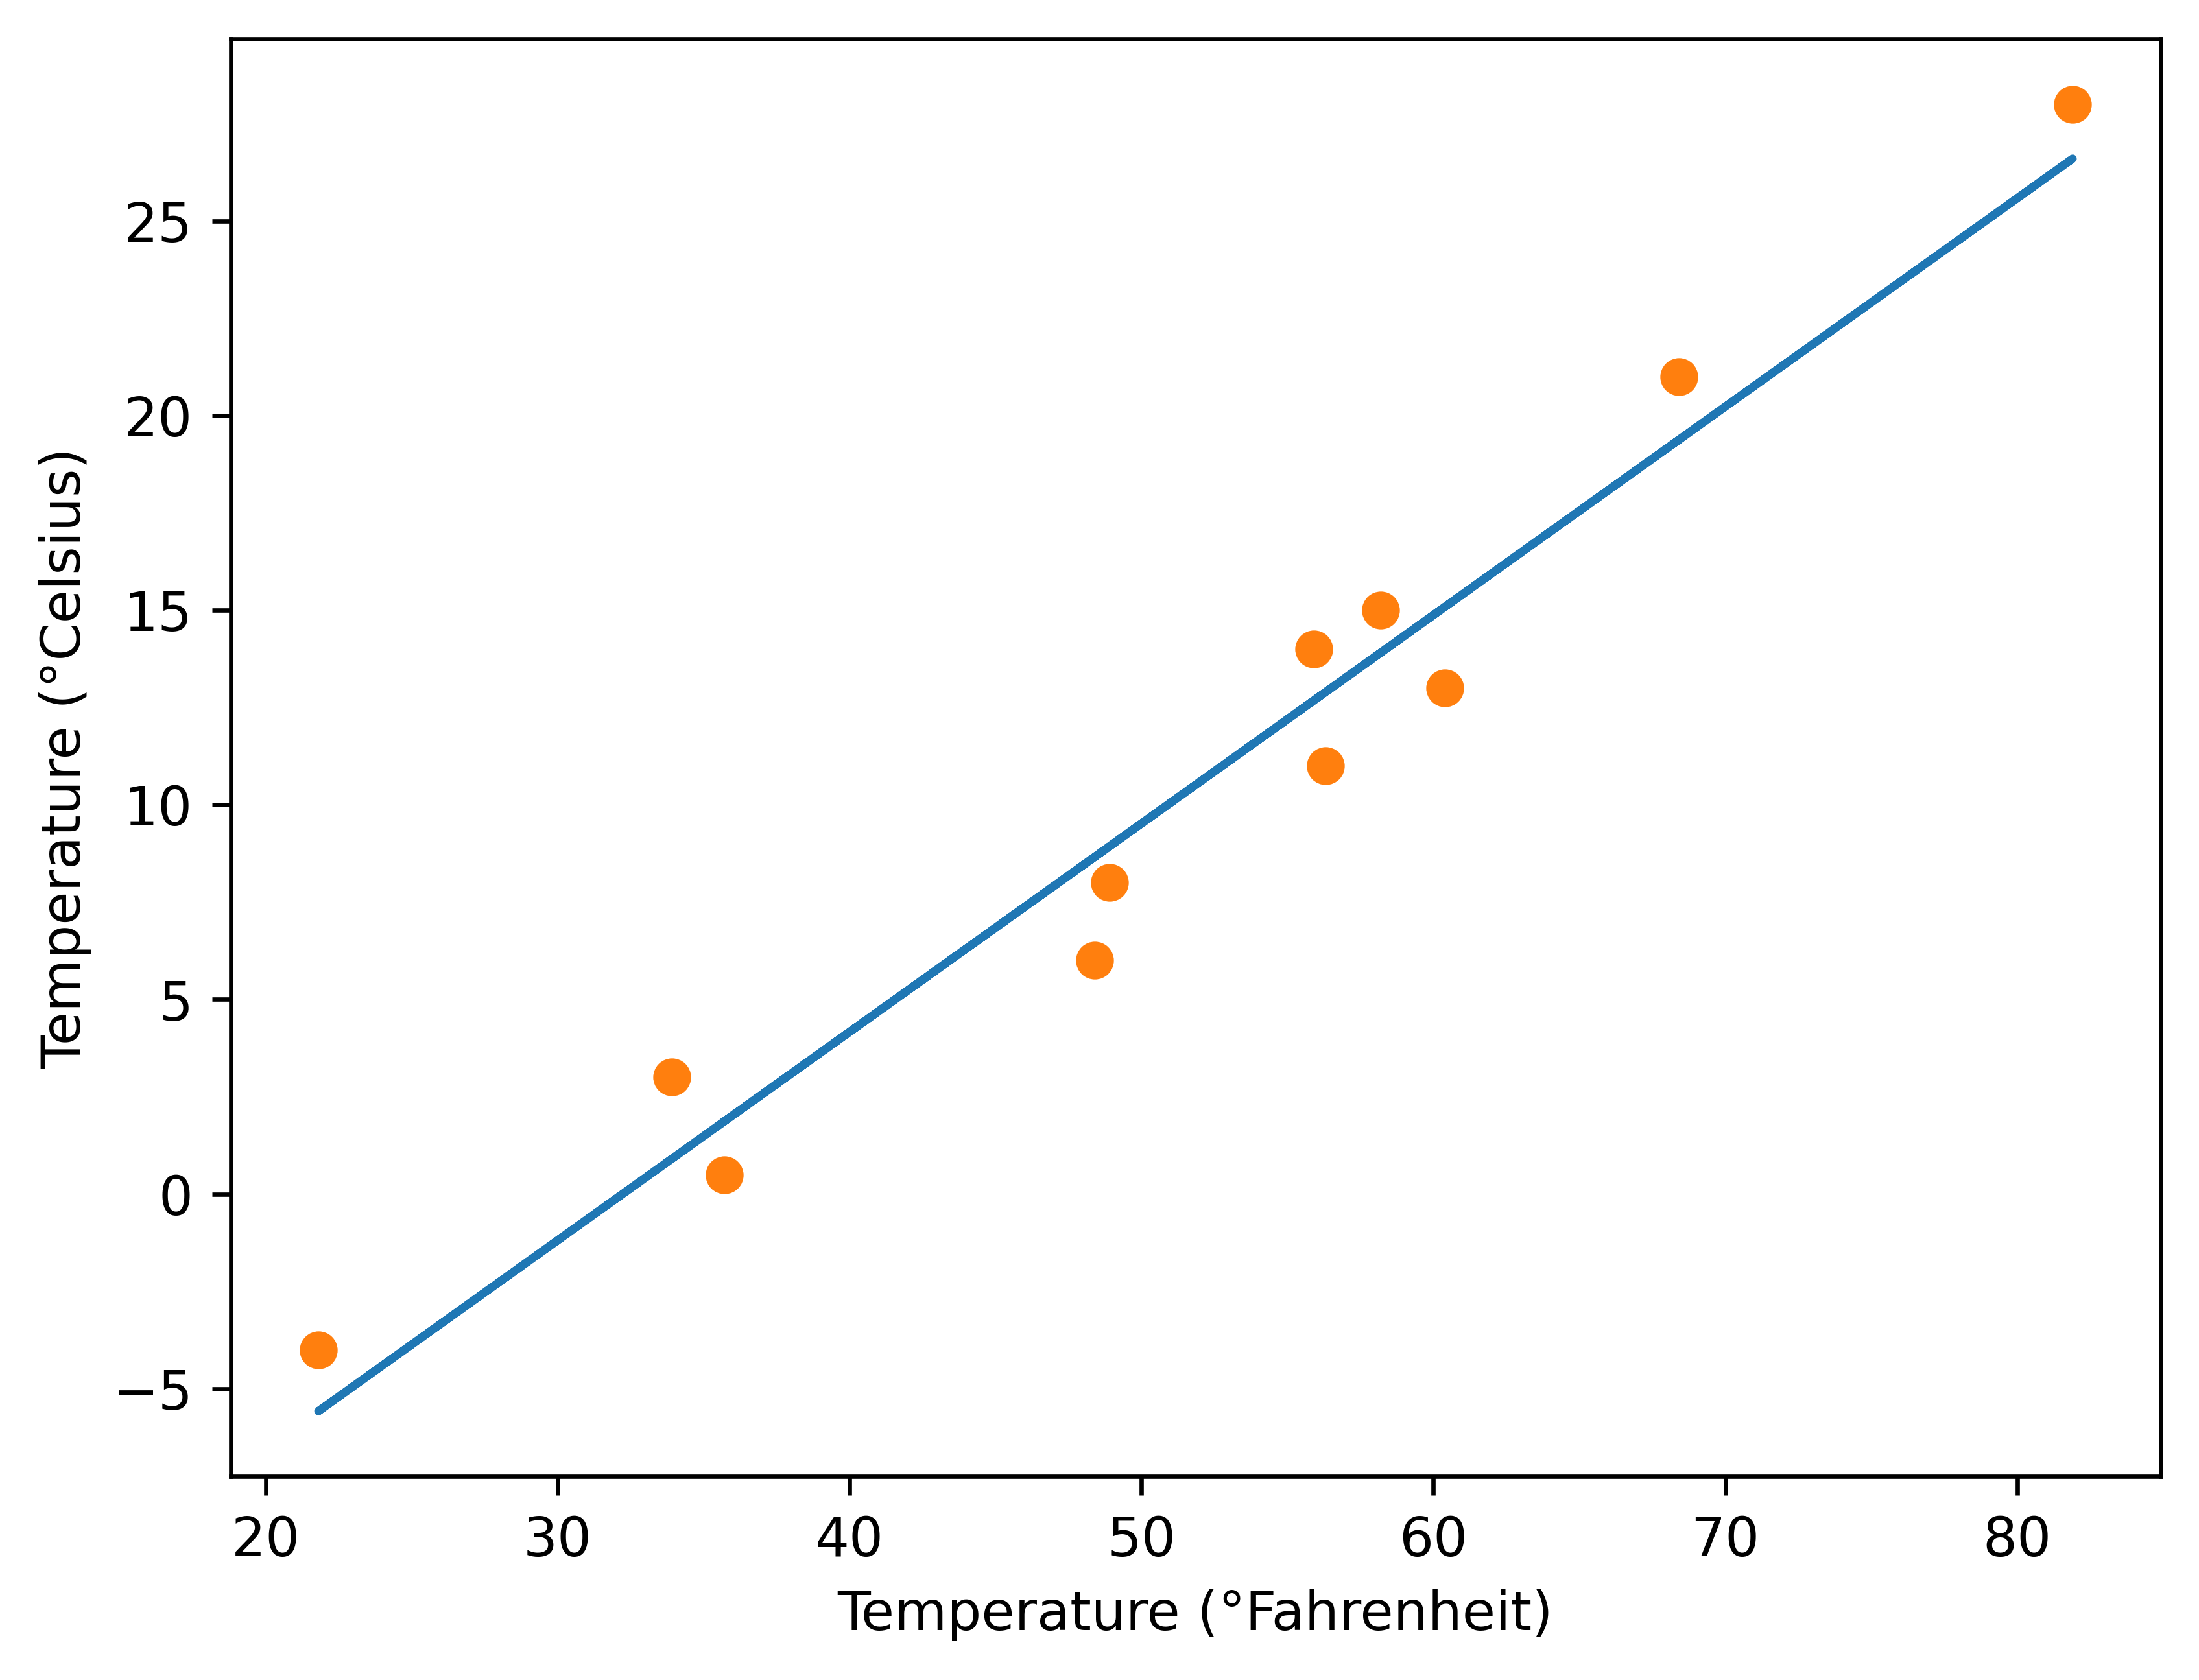

In [27]:
#Graficamos
t_p = model_T(t_un, params[0], params[1])
fig = plt.figure(dpi=600)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

Todo esto se puede simplificar utilizando las facilidades de la librería torch, entre ellas el cálculo de gradiente automático:

In [28]:
#Inicializamos el tensor de parámetros y le damos esta propiedad de gradiente
params = torch.tensor([1.0, 0.0], requires_grad=True)

In [29]:
loss = loss_fn(model_T(t_u, *params), t_c)
loss.backward()

params.grad     #Tensor con las derivadas de la función loss con respecto a los parámetros

tensor([4517.2969,   82.6000])

In [30]:
#Definismo nuevamente el entrenamiento
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:      #Es necesario eliminar el gradiente en cada paso o se aacumulará
            params.grad.zero_()

        t_p = model_T(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward()                 #Aquí calculamos el gradiente
        
        with torch.no_grad():
            params -= learning_rate * params.grad      #Aquí actualizamos
            
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

In [31]:
#Entrenamiento con variables normalizadas
training_loop(
n_epochs = 320,
learning_rate = 1e-2,
params = torch.tensor([1.0, 0.0], requires_grad=True),   #Le damos gradiente a los parámetros
t_u = t_un,       #Cambio a las variables normalizadas
t_c = t_c)

tensor([ 9.0123, 10.4837], requires_grad=True)

Otra propiedad de torch es que tiene distintos optimizadores (algoritmos como el de descenso de gradeinte). El proceso de trabajo de estos optimizadores es el de la imagen:

![](Optimizador.png)

In [32]:
import torch.optim as optim

dir(optim)

['ASGD',
 'Adadelta',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional',
 '_multi_tensor',
 'lr_scheduler',
 'swa_utils']

Vamos a implementar los optimizadores en nuestro modelo:

In [33]:
#Definimos los parámetros iniciales
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5

#Definimos el optimizador con optim
optimizer = optim.SGD([params], lr=learning_rate)

#Paso de entrenamiento
t_p = model_T(t_u, *params)
loss = loss_fn(t_p, t_c)
loss.backward()

optimizer.step()           #Aquí es donde se utiliza el optimizador

params                     #Ahora el tensor params se actualizó llamando .step()

tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)

Introducimos esto en el training_loop

In [38]:
#Entrenamiento con el módulo de optimizador para la actualización automática de params
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs+1):
        #Esto queda como antes
        t_p = model_T(t_u, *params)
        loss = loss_fn(t_p, t_c)

        optimizer.zero_grad()           #Reinicio del gradiente como antes
        loss.backward()                 #Cálulo del gradiente
        optimizer.step()                #Actualización

        if epoch % 50 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    
    return params

In [39]:
#Entrenamiento con .backward(), datos normalizados y optimizer.step()
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs = 350,
    optimizer = optimizer,
    params = params,
    t_u = t_un,
    t_c = t_c)

Epoch 50, Loss 27.870665
Epoch 100, Loss 6.498064
Epoch 150, Loss 3.443054
Epoch 200, Loss 3.002686
Epoch 250, Loss 2.938664
Epoch 300, Loss 2.929278
Epoch 350, Loss 2.927889


tensor([ 9.0219, 10.4911], requires_grad=True)

In [41]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate)

params = training_loop(
    n_epochs =350,
    optimizer = optimizer,
    params = params,
    t_u = t_un,
    t_c = t_c)

Epoch 50, Loss 49.795383
Epoch 100, Loss 10.921573
Epoch 150, Loss 3.812501
Epoch 200, Loss 2.987126
Epoch 250, Loss 2.929761
Epoch 300, Loss 2.927677
Epoch 350, Loss 2.927646


Otra de las cosas de las que uno tiene que tener cuidado es de la memorización en el modelo (overfitting). Este fenómeno se observa cuando el modelo obtiene errores bajos en el entrenamiento, pero al utilizar nuevos datos este no predice correctamente lo esperado.

![](Memorizacion.png)

Para monitorear este comportamiento vamos a separar los datos en datos que se usarán en el aprendizaje, y datos con los que validaremos este aprendizaje, de tal manera que si el error en los datos de aprendizaje baja pero no en los de validación el modelo memorizará y pararemos el entrenamiento. Los errores deben bajar con un ritmo semejante.

![](Aprendizaje_validacion.png)

In [152]:
#Separación de los datos
n_samples = t_u.shape[0]                 #Numero de muestras
n_val = int(0.2 * n_samples)             #Cantidad de muestras de validacion

#Se revuelven aleatoriamente los datos (para evitar sesgos)
shuffled_indices = torch.randperm(n_samples)

#Se asocian los datos
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

#Se normalizan respecto al total de datos
train_t_un = (train_t_u - t_u.mean())/t_u.std()
val_t_un = (val_t_u - t_u.mean())/t_u.std()
train_t_un, val_t_un, train_t_c, val_t_c

(tensor([-1.7823, -0.1723, -0.2020, -1.0635,  0.2673,  0.2436,  0.3802,  1.7883,
          0.9862]),
 tensor([ 0.5109, -0.9565]),
 tensor([-4.,  8.,  6.,  3., 11., 14., 15., 28., 21.]),
 tensor([13.0000,  0.5000]))

In [73]:
#Entrenamiento implementando el aprendizaje y validación
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        #Forward con datos de entrenamiento
        train_t_p = model_T(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        #Forward con datos de validación
        val_t_p = model_T(val_t_u, *params)
        val_loss = loss_fn(val_t_p, val_t_c)

        #Backpropagation
        optimizer.zero_grad()
        train_loss.backward()      #Esta es la parte importante, pues hace el proceso de backpropagation
        optimizer.step()           #respecto a train_loss y no respecto a val_loss

        if epoch <= 3 or epoch % 50 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"f" Validation loss {val_loss.item():.4f}")
    return params

Hay que notar que .backward y optimizer.step() actuan automáticamente solo en los primeros datos en los que evaluamos tanto el modelo como la función de error. Por lo que no hay oncfusión de que pueda estar calculando el gradiente y el cambio respecto a los datos de validación a menos que estén en orden inverso

In [74]:
#Parámetros iniciales
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

#Entrenamiento
training_loop(
n_epochs = 350,
optimizer = optimizer,
params = params,
train_t_u = train_t_un,
val_t_u = val_t_un,
train_t_c = train_t_c,
val_t_c = val_t_c)

Epoch 1, Training loss 148.2249, Validation loss 278.2640
Epoch 2, Training loss 143.4116, Validation loss 269.1979
Epoch 3, Training loss 138.7586, Validation loss 260.4314
Epoch 50, Training loss 30.9521, Validation loss 56.6690
Epoch 100, Training loss 8.1213, Validation loss 13.4771
Epoch 150, Training loss 3.8076, Validation loss 5.3926
Epoch 200, Training loss 2.9876, Validation loss 3.8864
Epoch 250, Training loss 2.8313, Validation loss 3.6099
Epoch 300, Training loss 2.8014, Validation loss 3.5610
Epoch 350, Training loss 2.7957, Validation loss 3.5531


tensor([ 8.9592, 10.5232], requires_grad=True)

Un paso cuando menos importante de mencionar es que para modelos grandes es bueno no permitir el gradiente de datos de validación pues esto en términos de memoria y velocidad es importante.

In [77]:
#Función de entrenamiento con .backward(), normalización de datos, optimizer.step(), validación, 
#y optimización de memoria
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        #Forward con datos de entrenamiento
        train_t_p = model_T(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        #Forward con datos de validación desavilitando su gradiente
        with torch.no_grad():
            val_t_p = model_T(val_t_u, *params)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False

        #Backpropagation
        optimizer.zero_grad()
        train_loss.backward()      #Esta es la parte importante, pues hace el proceso de backpropagation
        optimizer.step()           #respecto a train_loss y no respecto a val_loss

        if epoch <= 3 or epoch % 50 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"f" Validation loss {val_loss.item():.4f}")
    return params

Ahora podemos valernos del módulo nn de Torch que nos permite algunas facilidades

In [94]:
#Pasemos al uso del módulo nn de torch
import torch.nn as nn      #modulo nn

#Creamos un modelo lineal como antes pero con nn
linear_model = nn.Linear(1, 1)
#nn.Linear(n,m) crea una transfromación lineal (aleatoria) desplazada de R^n em R^m

t=torch.tensor([40.0])
linear_model(t)

tensor([-18.6714], grad_fn=<ViewBackward0>)

In [100]:
#Sus parámetros son:
linear_model.weight+linear_model.bias

tensor([[-0.2224]], grad_fn=<AddBackward0>)

In [114]:
x = torch.ones(10,1)
x, linear_model(x), linear_model.parameters()
#Equivale a evaluar por la izquierda las matrices xA y el bias se adapta a la dimensión de x

(tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.]]),
 tensor([[-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224],
         [-0.2224]], grad_fn=<AddmmBackward0>),
 <generator object Module.parameters at 0x7fa72ba0eb30>)

In [149]:
t_c2 = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u2 = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c2 = torch.tensor(t_c2)
t_u2 = torch.tensor(t_u2).unsqueeze(1)
t_u2.shape, t_u2, t_c2.shape, t_c2

(torch.Size([11, 1]),
 tensor([[35.7000],
         [55.9000],
         [58.2000],
         [81.9000],
         [56.3000],
         [48.9000],
         [33.9000],
         [21.8000],
         [48.4000],
         [60.4000],
         [68.4000]]),
 torch.Size([11]),
 tensor([ 0.5000, 14.0000, 15.0000, 28.0000, 11.0000,  8.0000,  3.0000, -4.0000,
          6.0000, 13.0000, 21.0000]))

Notamos que hay una ligera sutileza entre el array convertido directamente a tensor y como matriz columna.

In [159]:
#FUncion de entrenamiento implementando el módulo nn
def training_loop(n_epochs, optimizer, model, loss_fn, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        #Forward
        train_t_p = model(train_t_u)             #Ahora se llama al modelo directamente
        train_loss = loss_fn(train_t_p, train_t_c)

        with torch.no_grad():
            val_t_p = model(val_t_u)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False

        #Backpropagation
        optimizer.zero_grad()
        train_loss.backward()      
        optimizer.step()           

        if epoch <= 3 or epoch % 50 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"f" Validation loss {val_loss.item():.4f}")

In [160]:
#Convertimos los datos a vectores columnas
t_un_train = train_t_un.unsqueeze(1)
t_un_val = val_t_un.unsqueeze(1)
t_c_train = train_t_c.unsqueeze(1)
t_c_val = val_t_c.unsqueeze(1)

In [157]:
#Entrenamiento con datos normalizados, .bacward(), optimizer.step(), validacion, y módulo nn
linear_model = nn.Linear(1, 1)                                   #Definimos el modelo lineal
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)        
#Directamente en optimizer damos lr y definimos los parámetros como atributo de nn.Linear

training_loop(
    n_epochs = 350,                         
    optimizer = optimizer,            #optimizador
    model = linear_model,             #modelo
    loss_fn = nn.MSELoss(),           #Función de error desde nn
    train_t_u = t_un_train,
    val_t_u = t_un_val,
    train_t_c = t_c_train,
    val_t_c = t_c_val)

print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 230.8387, Validation loss 92.9833
Epoch 2, Training loss 221.4426, Validation loss 88.4621
Epoch 3, Training loss 212.4335, Validation loss 84.1457
Epoch 50, Training loss 31.7678, Validation loss 6.0191
Epoch 100, Training loss 6.2704, Validation loss 1.3677
Epoch 150, Training loss 3.1577, Validation loss 3.0680
Epoch 200, Training loss 2.7776, Validation loss 4.0632
Epoch 250, Training loss 2.7313, Validation loss 4.4584
Epoch 300, Training loss 2.7256, Validation loss 4.6017
Epoch 350, Training loss 2.7249, Validation loss 4.6522
Epoch 400, Training loss 2.7248, Validation loss 4.6698
Parameter containing:
tensor([[8.9884]], requires_grad=True)
Parameter containing:
tensor([10.8858], requires_grad=True)


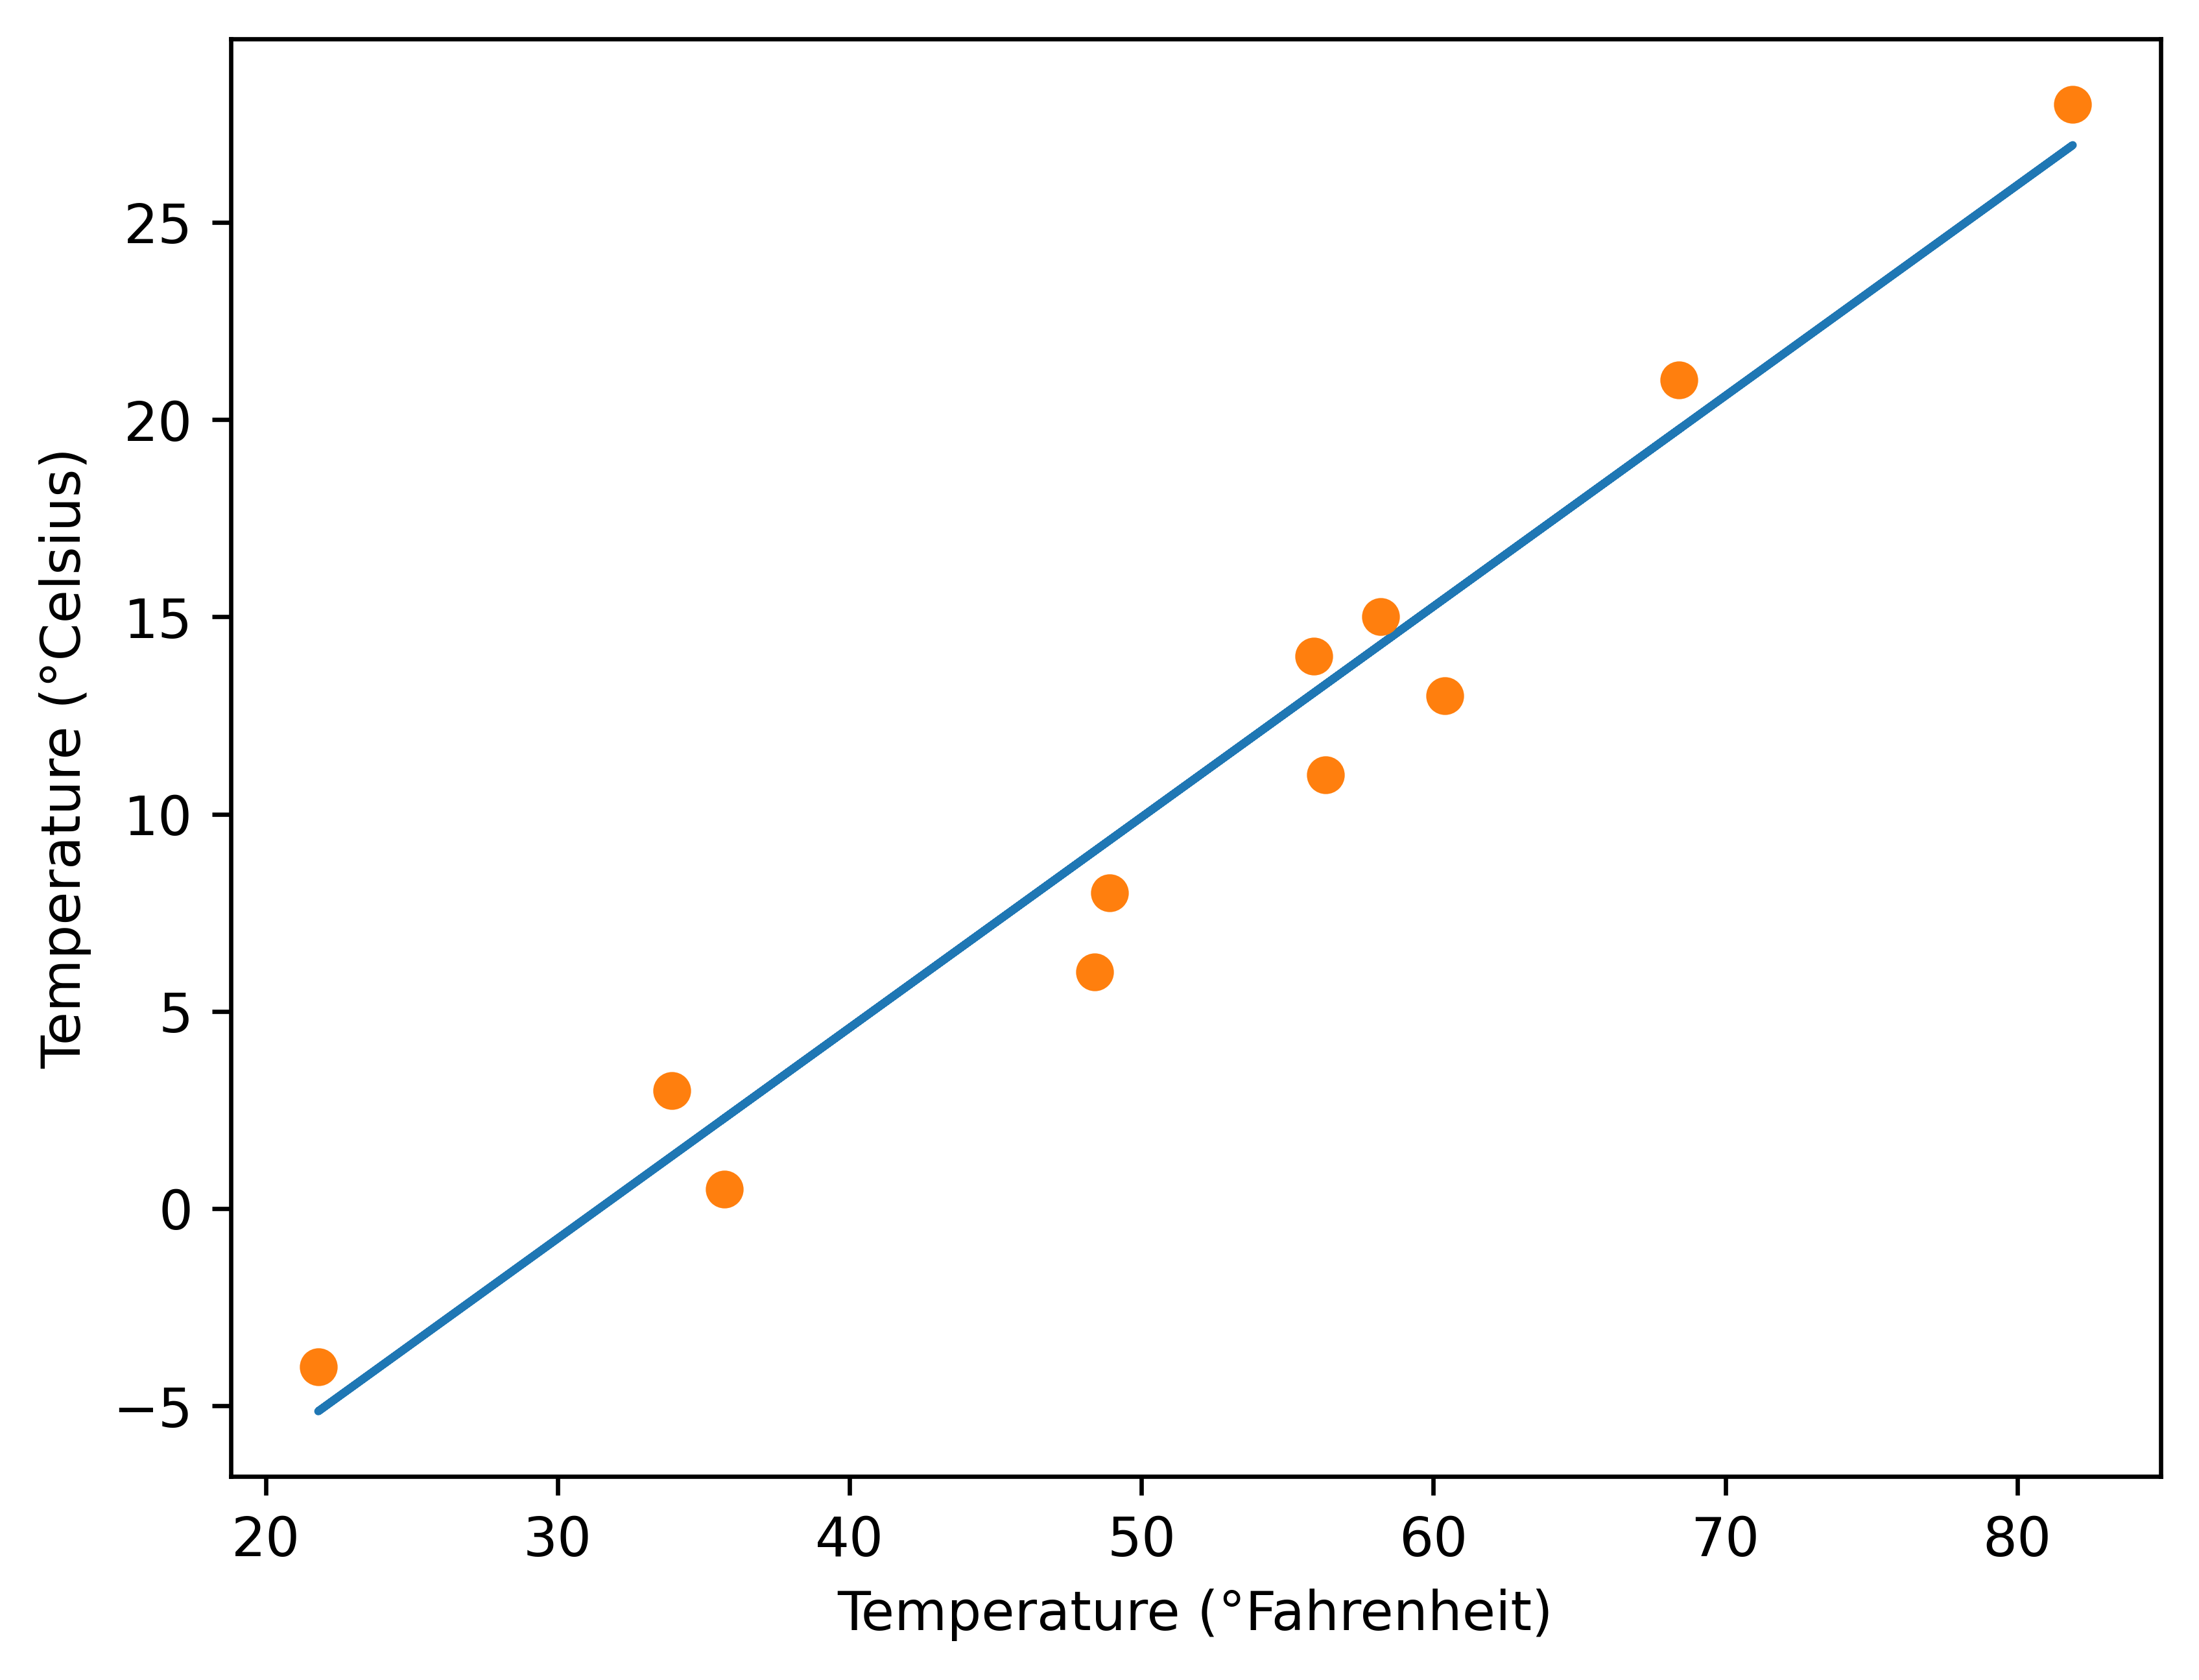

In [162]:
#Graficamos
t_p = linear_model(t_un.unsqueeze(1))
fig = plt.figure(dpi=600)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

Ya vimos cual es el proceso de aprendizaje supervisado. Este tiene algoritmos que podemos cambiar como la función de error y el optimizador. Y con lo anterior observamos que las funciones lineales son sencillas de modelar. Sin embargo, la gran mayoría de problemas son no lineales.

Vamos a definir una neurona como una función no lineal (función de activación) compuesta con una función lineal desplazada del origen

![](Neurona.png)

Este método es conocido como Perceptron.

Dentro de las poscibles funciones de activación están estas:

![](Funciones_de_activacion.png)

La idea es que introduzcamos un valor de entrada, pase por un modelo lineal, pase por la función no lineal y regrese un valor:

![](1layer.png)

In [165]:
#Usando nn, podemos definir modelos más complejos
seq_model = nn.Sequential(
    nn.Linear(1,13),          #Cada uno de los 13 elementos aquí los podemos pensar como una neurona en sí
    nn.Tanh(),
    nn.Linear(13,1)
    )
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [189]:
#Nombraremos cada parámetro de manera más intuitiva
from collections import OrderedDict        #Biblioteca para nombrar

#Definimos el modelo
seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1,8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8,1))
    ]))

#Mostramos la estructura con nombres
seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [190]:
#Podemos ver especificamente las dimensiones de cada parte
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [206]:
#Entrenamiento con datos normalizados, .bacward(), optimizer.step(), validacion, módulo nn, y capa oculta
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)

training_loop(
    n_epochs = 1000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    train_t_u = t_un_train,
    val_t_u = t_un_val,
    train_t_c = t_c_train,
    val_t_c = t_c_val)

print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.shape)
print('hidden', seq_model.output_linear.weight.grad)

Epoch 1, Training loss 1.4375, Validation loss 5.4271
Epoch 2, Training loss 1.4374, Validation loss 5.4273
Epoch 3, Training loss 1.4373, Validation loss 5.4274
Epoch 50, Training loss 1.4322, Validation loss 5.4351
Epoch 100, Training loss 1.4267, Validation loss 5.4443
Epoch 150, Training loss 1.4212, Validation loss 5.4543
Epoch 200, Training loss 1.4158, Validation loss 5.4653
Epoch 250, Training loss 1.4103, Validation loss 5.4771
Epoch 300, Training loss 1.4048, Validation loss 5.4897
Epoch 350, Training loss 1.3994, Validation loss 5.5031
Epoch 400, Training loss 1.3939, Validation loss 5.5172
Epoch 450, Training loss 1.3885, Validation loss 5.5320
Epoch 500, Training loss 1.3830, Validation loss 5.5473
Epoch 550, Training loss 1.3776, Validation loss 5.5633
Epoch 600, Training loss 1.3722, Validation loss 5.5799
Epoch 650, Training loss 1.3668, Validation loss 5.5969
Epoch 700, Training loss 1.3614, Validation loss 5.6144
Epoch 750, Training loss 1.3560, Validation loss 5.6323

In [200]:
print(t_un)
seq_model(t_un) #Esto da un error debido a que no sob objetos de dimensiones compatibles (1x11)(1x8)
#No hay que dejarse engañar por los objetos que se usan

tensor([-0.9565,  0.2436,  0.3802,  1.7883,  0.2673, -0.1723, -1.0635, -1.7823,
        -0.2020,  0.5109,  0.9862])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x11 and 1x8)

In [205]:
t_un.unsqueeze(1), seq_model(t_un.unsqueeze(1))
#Ahora si se puede pues el primero es un vector (11x1)(1x8)

(tensor([[-0.9565],
         [ 0.2436],
         [ 0.3802],
         [ 1.7883],
         [ 0.2673],
         [-0.1723],
         [-1.0635],
         [-1.7823],
         [-0.2020],
         [ 0.5109],
         [ 0.9862]]),
 tensor([[ 2.4849],
         [12.2005],
         [13.8916],
         [27.3096],
         [12.4833],
         [ 8.0638],
         [ 1.7503],
         [-3.5656],
         [ 7.8193],
         [15.6295],
         [21.8541]], grad_fn=<AddmmBackward0>))

In [203]:
torch.tensor([0.4]), seq_model(torch.tensor([0.4]))
#Vemos que funciona con valores unitarios pues un valor unitario sería (1x1)(1x8)

(tensor([0.4000]), tensor([14.1482], grad_fn=<ViewBackward0>))

Ló unico inusual que se debe observar es que a nivel computacional la multiplicacion en el modelo se hace por la izquierda  por eso la primer capa oculta se define con el número de elementos en los que la función será evaluada con normalidad (vectores n dimensionales en forma de renglón (1xn) y la capa queda definida como nn.Linear(n,m) donde m es un valor arbitrario). Por eso cuando se evalúa en conjuntos de k vectores con n entradas (kxn) el entrenamiento funciona.

Sin embargo, la visualización de esas capas ocultas o de salida nos las motrará transpuestas, pues es más usual la multiplicación por la derecha tnto matemáticamente como en programación.

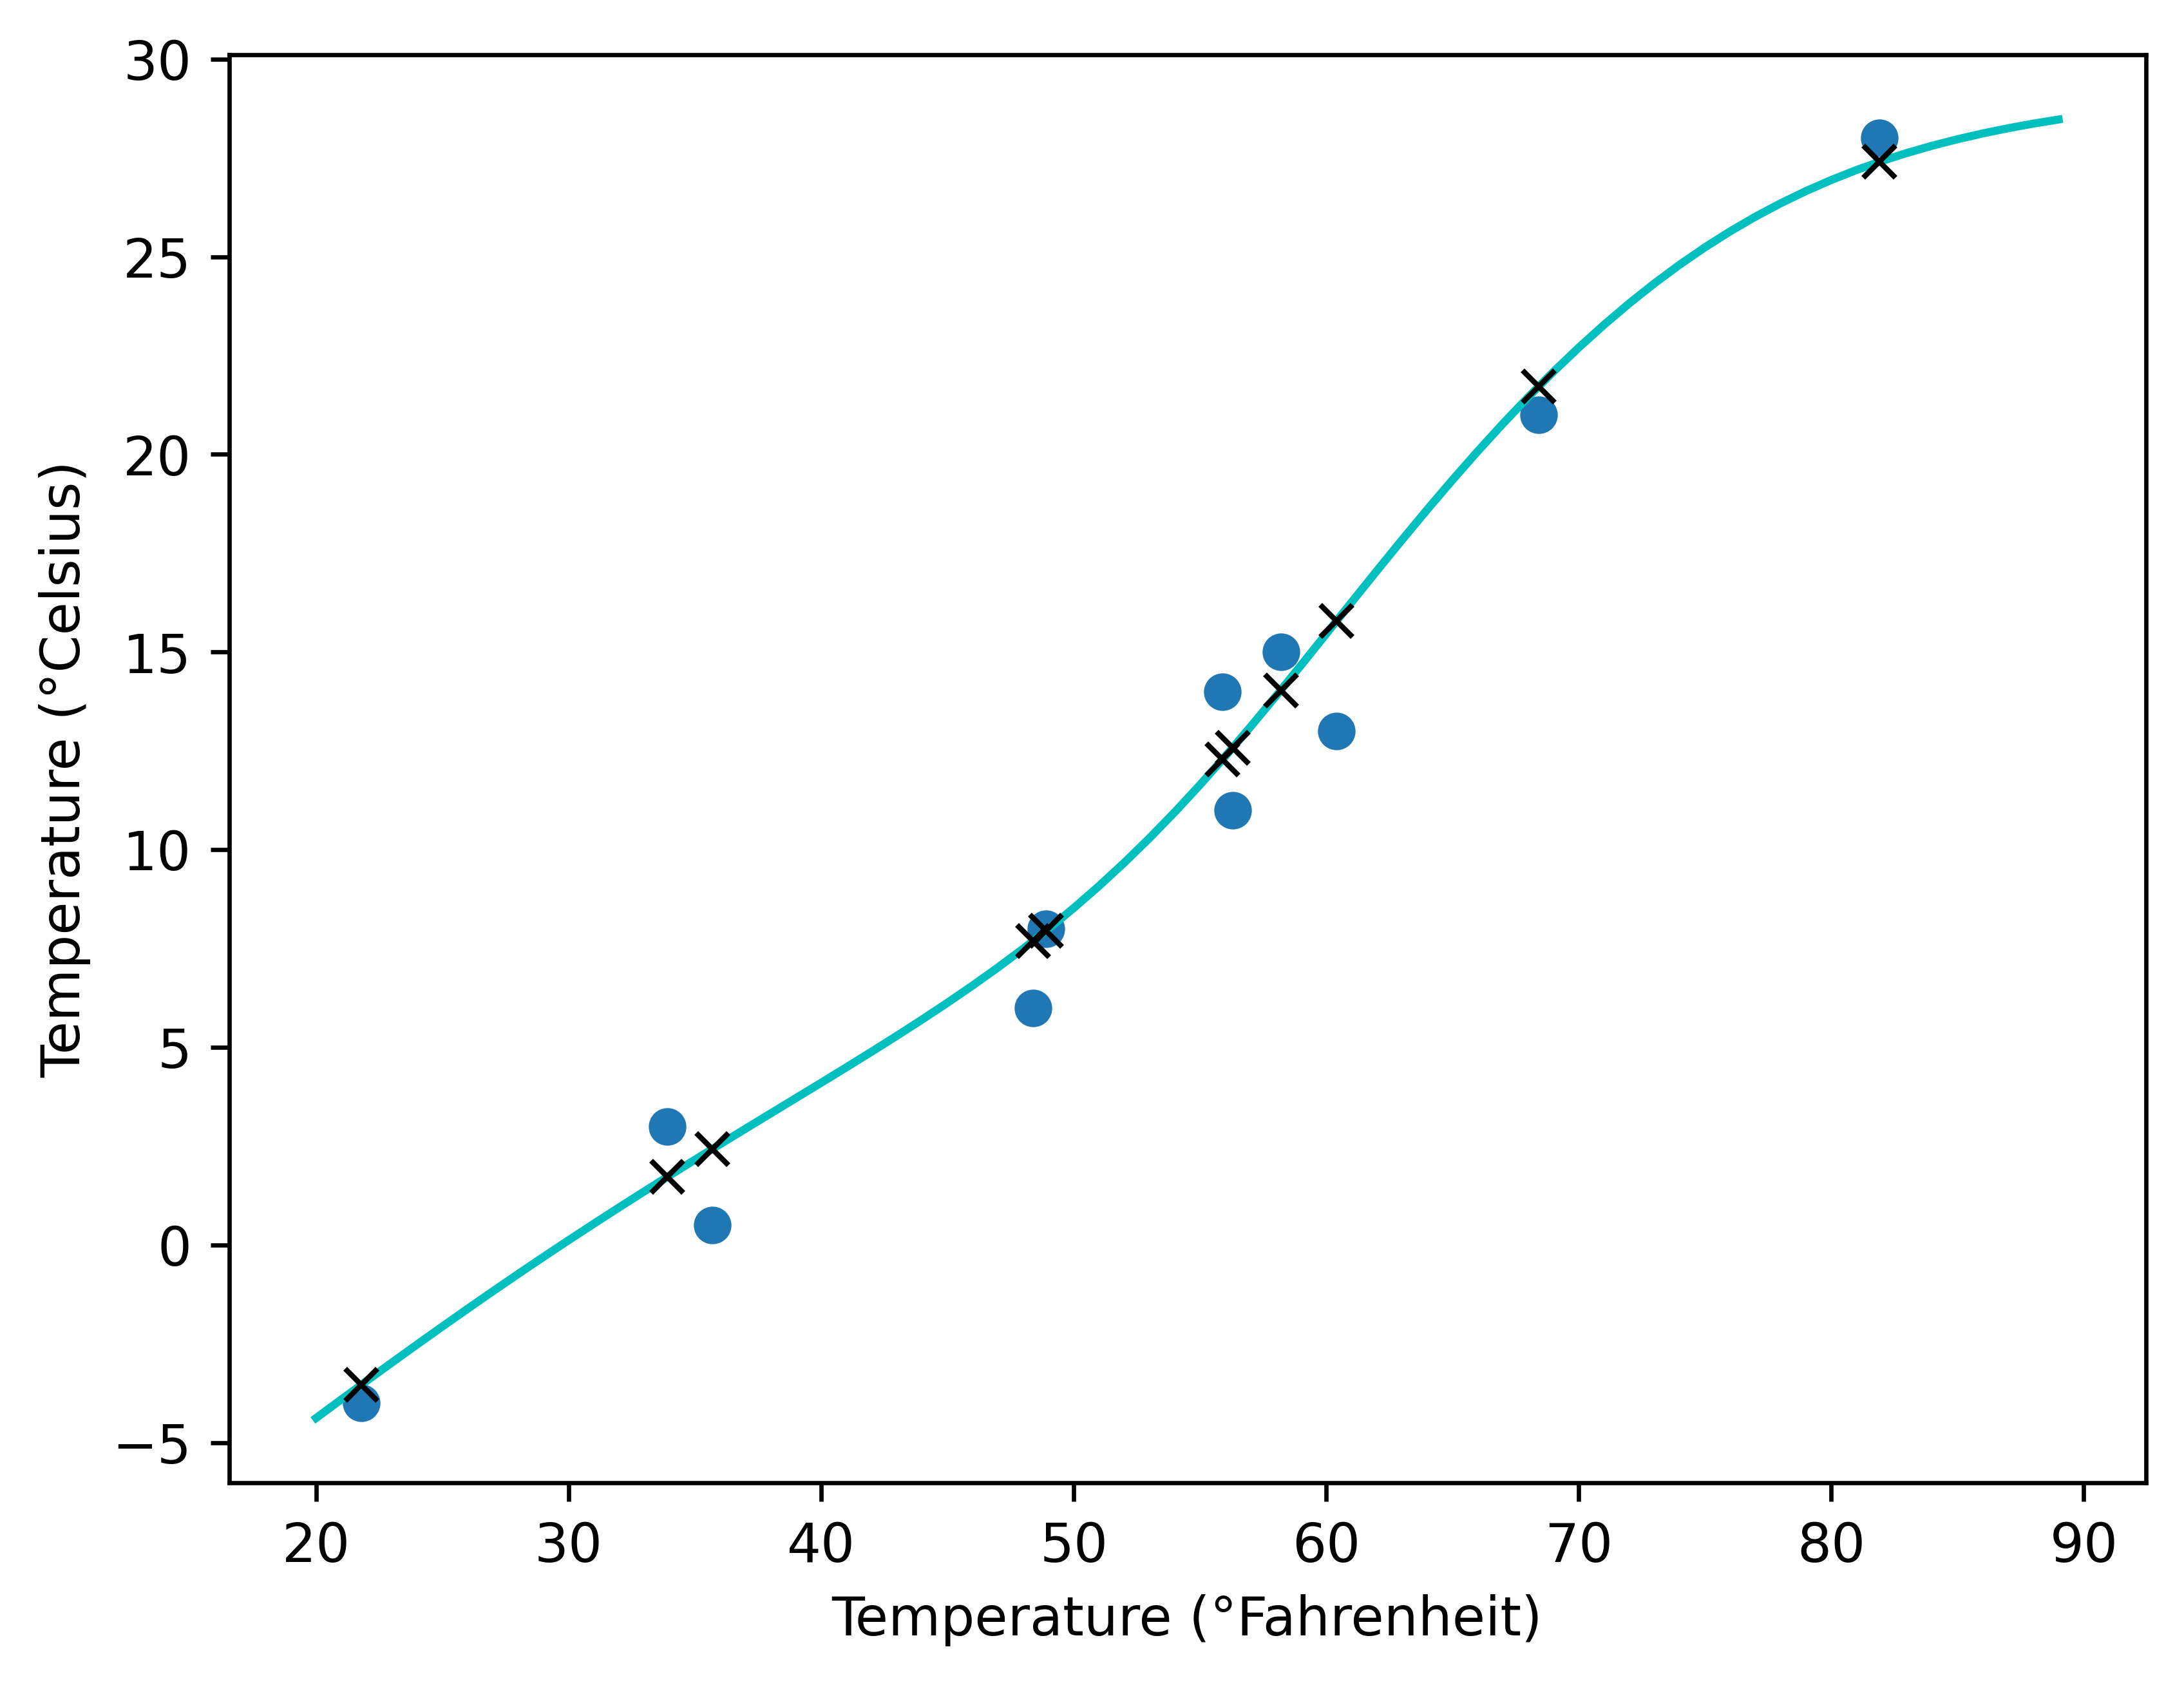

In [222]:
#Graficamos
t_range = torch.arange(20.,90.).unsqueeze(1)     #Damos el rango en forma de tensor columna para evaluar
fig = plt.figure(dpi=600)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
#Hacemos la normalización dentro de la evalución para no afectar el rango de graficación
plt.plot(t_range.numpy(), seq_model((t_range-t_u.mean())/t_u.std()).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model((t_u.unsqueeze(1)-t_u.mean())/t_u.std()).detach().numpy(), 'kx')

tensor(1.7883)